In [1]:
import sys
print(sys.executable)
import nlb_tools, pynwb, sklearn, matplotlib
print("kernel works")

c:\Users\darth\miniconda3\envs\neurodecode\python.exe
kernel works


In [2]:
from nlb_tools.nwb_interface import NWBDataset

dataset = NWBDataset("../data/000140/sub-Jenkins/", "*train", split_heldout=False)
print(dataset.data.shape)
print(dataset.trial_info.head())

(293666, 150)
   trial_id             start_time               end_time  trial_type  \
0         0        0 days 00:00:00 0 days 00:00:03.421000          11   
1         1 0 days 00:00:03.500000 0 days 00:00:05.631000          12   
2         2 0 days 00:00:05.700000 0 days 00:00:08.536000           4   
3         3 0 days 00:00:08.600000 0 days 00:00:11.746000           8   
4         4 0 days 00:00:11.800000 0 days 00:00:14.706000           7   

   trial_version  maze_id  success         target_on_time  \
0              1       76     True 0 days 00:00:00.848000   
1              0       77     True 0 days 00:00:04.176000   
2              1        4     True 0 days 00:00:06.359000   
3              2       10     True 0 days 00:00:09.361000   
4              2        8     True 0 days 00:00:12.593000   

             go_cue_time        move_onset_time   rt  delay  num_targets  \
0 0 days 00:00:01.413000 0 days 00:00:02.171000  758    565            1   
1 0 days 00:00:04.324000 0 d

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nlb_tools.nwb_interface import NWBDataset

os.makedirs("../figures", exist_ok=True)
dataset = NWBDataset("../data/000140/sub-Jenkins/", "*train", split_heldout=False)

# Workaround for newer pandas: snap timestamps to whole milliseconds and merge
# rows that land on the same millisecond, so the time grid is perfectly regular.
steps = lambda idx: np.unique(np.diff(idx.asi8))[:5]
print("before:", len(dataset.data), "rows | step sizes (ns):", steps(dataset.data.index))
dataset.data.index = dataset.data.index.round("ms")
dataset.data = dataset.data.groupby(level=0).first()
dataset.data.index.name = "clock_time"
print("after: ", len(dataset.data), "rows | step sizes (ns):", steps(dataset.data.index))

dataset.resample(20)                  # 20 ms bins
dataset.smooth_spk(40, name="smth")   # smoothed copy of the spikes, for PSTHs

print(dataset.data.columns.get_level_values(0).unique().tolist())
print(dataset.trial_info.columns.tolist())
print("neurons:", dataset.data["spikes"].shape[1], "| trials:", len(dataset.trial_info))

before: 293666 rows | step sizes (ns): [-290244000000       1000000      15000000      20000000      25000000]
after:  293666 rows | step sizes (ns): [1000000]
['cursor_pos', 'eye_pos', 'hand_pos', 'hand_vel', 'spikes', 'spikes_smth']
['trial_id', 'start_time', 'end_time', 'trial_type', 'trial_version', 'maze_id', 'success', 'target_on_time', 'go_cue_time', 'move_onset_time', 'rt', 'delay', 'num_targets', 'target_pos', 'num_barriers', 'barrier_pos', 'active_target', 'split']
neurons: 142 | trials: 100


In [6]:
trials = dataset.make_trial_data(align_field="move_onset_time", align_range=(-250, 450))
t_ms = trials["align_time"].dt.total_seconds().mul(1000).round().astype(int)
trial_ids = trials["trial_id"].unique()

angles = {}
for tid in trial_ids:
    pos = trials.loc[trials["trial_id"] == tid, "hand_pos"].values
    dx, dy = pos[-1] - pos[0]
    angles[tid] = np.arctan2(dy, dx)
print(len(trial_ids), "trials aligned")

100 trials aligned


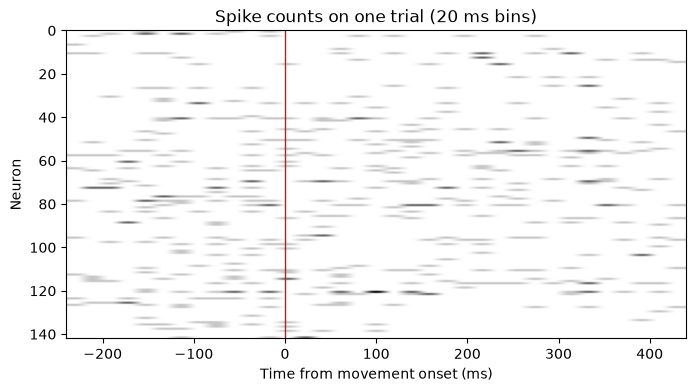

In [7]:
first = trials[trials["trial_id"] == trial_ids[0]]
tt = t_ms[first.index]
plt.figure(figsize=(8, 4))
plt.imshow(first["spikes"].T.values, aspect="auto", cmap="Greys",
           extent=[tt.iloc[0], tt.iloc[-1], first["spikes"].shape[1], 0])
plt.axvline(0, color="red", lw=1)
plt.xlabel("Time from movement onset (ms)"); plt.ylabel("Neuron")
plt.title("Spike counts on one trial (20 ms bins)")
plt.savefig("../figures/01_single_trial.png", dpi=150, bbox_inches="tight")

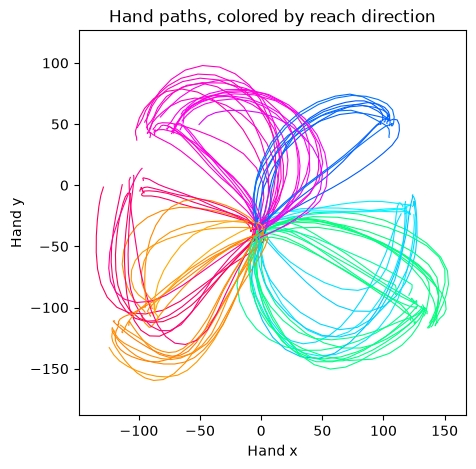

In [8]:
cmap = plt.cm.hsv
plt.figure(figsize=(5, 5))
for tid in trial_ids:
    pos = trials.loc[trials["trial_id"] == tid, "hand_pos"]
    plt.plot(pos["x"], pos["y"], color=cmap((angles[tid] + np.pi) / (2 * np.pi)), lw=0.8)
plt.axis("equal"); plt.xlabel("Hand x"); plt.ylabel("Hand y")
plt.title("Hand paths, colored by reach direction")
plt.savefig("../figures/02_hand_paths.png", dpi=150, bbox_inches="tight")

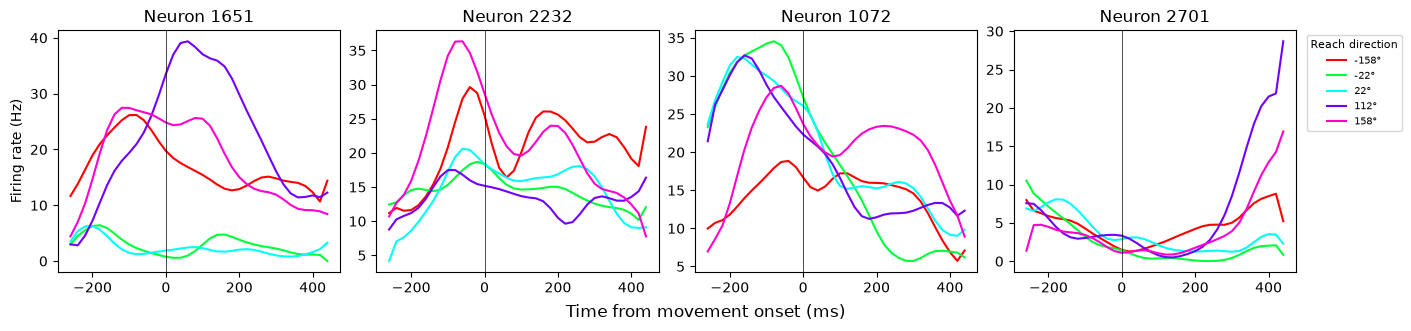

In [11]:
# Figure 3: PSTHs for the 4 most strongly modulated neurons, split into 8 reach directions
rates = trials["spikes_smth"] / 0.020                    # spikes per second
dir_bin = {tid: int((a + np.pi) / (2 * np.pi) * 8) % 8 for tid, a in angles.items()}
bins = trials["trial_id"].map(dir_bin).values

# Average over trials for each (direction, time), then rank neurons by how much their rate changes
psth_all = rates.groupby([bins, t_ms.values]).mean()
modulation = psth_all.max() - psth_all.min()
top = modulation.nlargest(4).index

centers = -180 + 22.5 + 45 * np.arange(8)                # center of each direction bin, in degrees
present = set(psth_all.index.get_level_values(0))
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharex=True, constrained_layout=True)
for ax, n in zip(axes, top):
    for b in range(8):
        if b not in present:                             # skip directions with no trials
            continue
        psth = psth_all.loc[b, n]
        ax.plot(psth.index, psth.values, color=cmap(b / 8), label=f"{centers[b]:.0f}°")
    ax.axvline(0, color="k", lw=0.5)
    ax.set_title(f"Neuron {n}")
axes[0].set_ylabel("Firing rate (Hz)")
fig.supxlabel("Time from movement onset (ms)")
axes[-1].legend(title="Reach direction", fontsize=7, title_fontsize=8,
                loc="upper left", bbox_to_anchor=(1.02, 1))
plt.savefig("../figures/03_psths.png", dpi=150, bbox_inches="tight")

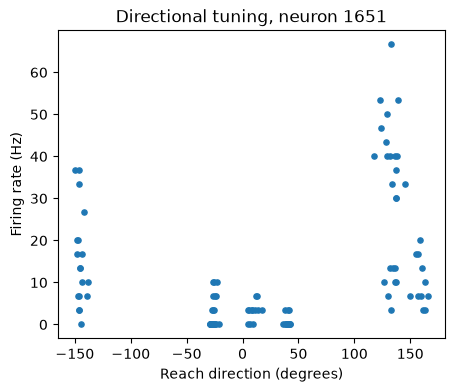

In [16]:
straight = dataset.trial_info.loc[dataset.trial_info["num_barriers"] == 0, "trial_id"]
rate = rate[rate.index.isin(straight)]
ang = np.degrees([angles[t] for t in rate.index])

w = ((t_ms >= 0) & (t_ms < 300)).values
rate = trials.loc[w, "spikes"].groupby(trials.loc[w, "trial_id"].values).sum() / 0.3
ang = np.degrees([angles[t] for t in rate.index])
n = top[0]
plt.figure(figsize=(5, 4))
plt.scatter(ang, rate[n], s=14)
plt.xlabel("Reach direction (degrees)"); plt.ylabel("Firing rate (Hz)")
plt.title(f"Directional tuning, neuron {n}")
plt.savefig("../figures/04_tuning.png", dpi=150, bbox_inches="tight")